# Inferencia en CPU — Detección de Comercio Informal (Santa Cruz)


## 1. Dependencias y verificación del entorno


In [1]:
try:
    import ultralytics  
except ImportError:
    %pip install -q ultralytics==8.4.123

In [2]:
import os
import glob
import time
from collections import Counter
from pathlib import Path

import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Forzamos CPU aunque hubiera GPU disponible: el objetivo de este notebook es
# demostrar que el modelo funciona sin CUDA.
DISPOSITIVO = 'cpu'
torch.set_num_threads(os.cpu_count() or 1)

print('Versión de torch:  ', torch.__version__)
print('¿CUDA disponible?: ', torch.cuda.is_available())
print('Dispositivo usado: ', DISPOSITIVO)


Versión de torch:   2.5.1+cu121
¿CUDA disponible?:  True
Dispositivo usado:  cpu


## 2. Ubicar el repositorio

El notebook localiza la raíz del proyecto subiendo carpetas hasta encontrar
`requirements.txt` y `src/`. Así funciona igual si se ejecuta desde `notebooks/`
(lo habitual en VS Code y Jupyter) o desde la raíz del repositorio.


In [3]:
def raiz_repositorio(inicio=None):
    p = Path(inicio or os.getcwd()).resolve()
    for candidata in [p, *p.parents]:
        if (candidata / 'requirements.txt').exists() and (candidata / 'src').is_dir():
            return candidata
    raise FileNotFoundError(
        f'No encontré la raíz del repositorio partiendo de {p}. '
        'Abrí la carpeta del proyecto completa en VS Code, no solo notebooks/.')

RAIZ = raiz_repositorio()
RUTA_MODELO = RAIZ / 'modelos' / 'best_scz_transfer.pt'
DIR_IMAGENES = RAIZ / 'datos' / 'muestra' / 'images'
DIR_LABELS = RAIZ / 'datos' / 'muestra' / 'labels'

print('Raíz del repositorio:', RAIZ)
print('Modelo esperado en:  ', RUTA_MODELO.relative_to(RAIZ))
print('Imágenes esperadas en:', DIR_IMAGENES.relative_to(RAIZ))


Raíz del repositorio: C:\Users\Patricia\Modulo 2\Deteccion-Comercio-Informal-SCZ
Modelo esperado en:   modelos\best_scz_transfer.pt
Imágenes esperadas en: datos\muestra\images


## 3. Obtener los pesos entrenados

Los pesos no se versionan en el repositorio: están excluidos por `.gitignore` y se
distribuyen por enlace (ver `README.md`). Si el archivo ya está en `modelos/`, esta
celda no hace nada; si no está, lo descarga de Google Drive.

> `ID_MODELO` es la parte del enlace del **archivo** en Drive que va entre `/d/` y
> `/view`, y el archivo tiene que estar compartido como *Cualquier persona con el
> enlace*. Si el `.pt` ya está en su sitio, no hace falta completarlo.


In [4]:
ID_MODELO = ''  

RUTA_MODELO.parent.mkdir(parents=True, exist_ok=True)

if not RUTA_MODELO.exists():
    if not ID_MODELO:
        raise FileNotFoundError(
            f'No está {RUTA_MODELO}.\n'
            'Copiá ahí el archivo best_scz_transfer.pt, o completá ID_MODELO con el '
            'identificador del archivo en Google Drive.')
    try:
        import gdown
    except ImportError:
        raise SystemExit('Falta gdown. Instalalo con: pip install gdown')
    print('Descargando pesos desde Google Drive...')
    gdown.download(id=ID_MODELO, output=str(RUTA_MODELO), quiet=False)

tam_mb = RUTA_MODELO.stat().st_size / 1e6
print(f'Pesos encontrados: {RUTA_MODELO.name}  ({tam_mb:.2f} MB)')


if tam_mb < 1:
    raise ValueError('El archivo pesa menos de 1 MB: no es un checkpoint válido. '
                     'Revisá los permisos de compartición en Drive.')


Pesos encontrados: best_scz_transfer.pt  (5.47 MB)


## 4. Prueba explícita de carga con `map_location="cpu"`

El modelo se entrenó en GPU (Tesla T4). Esta celda confirma que el checkpoint se
deserializa correctamente en una máquina sin CUDA — que es exactamente lo que pide
la consigna del proyecto.


Demuestra el requisito de CPU del inferencia_cpu.ipynb: prueba que tus pesos se pueden cargar en una máquina sin GPU.

In [5]:
ckpt = torch.load(RUTA_MODELO, map_location='cpu', weights_only=False)

print('Checkpoint deserializado en CPU sin errores.')
print('Época del checkpoint:', ckpt.get('epoch'))
modelo_interno = ckpt.get('model')
if hasattr(modelo_interno, 'names'):
    print('Clases del checkpoint:', modelo_interno.names)

del ckpt, modelo_interno   # seguimos con la API de Ultralytics


Checkpoint deserializado en CPU sin errores.
Época del checkpoint: -1
Clases del checkpoint: {0: 'car', 1: 'van', 2: 'truck', 3: 'pedestrian', 4: 'person_sitting', 5: 'cyclist', 6: 'street_vendor', 7: 'street_stall', 8: 'motorbike'}


Carga por la vía normal y verifica que lo que quedó en memoria es el modelo correcto.

In [6]:
modelo = YOLO(str(RUTA_MODELO))
modelo.to(DISPOSITIVO)

n_params = sum(p.numel() for p in modelo.model.parameters())
print(f'Modelo YOLO11n cargado en {DISPOSITIVO}. Parámetros: {n_params:,}')
print('Clases:', modelo.names)


Modelo YOLO11n cargado en cpu. Parámetros: 2,591,595
Clases: {0: 'car', 1: 'van', 2: 'truck', 3: 'pedestrian', 4: 'person_sitting', 5: 'cyclist', 6: 'street_vendor', 7: 'street_stall', 8: 'motorbike'}


## 5. Imágenes de ejemplo

Se usan las fotos de `datos/muestra/images/`, incluidas en el repositorio junto con
sus anotaciones. Para probar con otras imágenes, basta cambiar `DIR_IMAGENES`.


In [7]:
EXTENSIONES = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')

imagenes = []
for ext in EXTENSIONES:
    imagenes.extend(DIR_IMAGENES.glob(ext))
imagenes = sorted(set(imagenes))

if not imagenes:
    raise FileNotFoundError(
        f'No hay imágenes en {DIR_IMAGENES}.\n'
        'Copiá ahí unas fotos de ejemplo con sus .txt en datos/muestra/labels/.')

print(f'{len(imagenes)} imágenes de ejemplo:')
for p in imagenes:
    print('  -', p.name)


16 imágenes de ejemplo:
  - 20260816_123129.jpg
  - 20260816_124322.jpg
  - 20260816_124559.jpg
  - 20260816_124602.jpg
  - 20260816_124659.jpg
  - 20260816_124758.jpg
  - 20260816_124852.jpg
  - 20260816_124924.jpg
  - 20260816_125125.jpg
  - 20260816_125135.jpg
  - 20260816_125224.jpg
  - 20260816_125822.jpg
  - 20260816_130039.jpg
  - IMG_20260815_160235.jpg
  - IMG_20260815_164504.jpg
  - IMG_20260815_165811.jpg


## 6. Inferencia y visualización


20260816_123129.jpg: 8 detecciones  ->  pedestrian 0.88, pedestrian 0.83, pedestrian 0.70, pedestrian 0.64, truck 0.63, street_stall 0.58, pedestrian 0.49, pedestrian 0.33


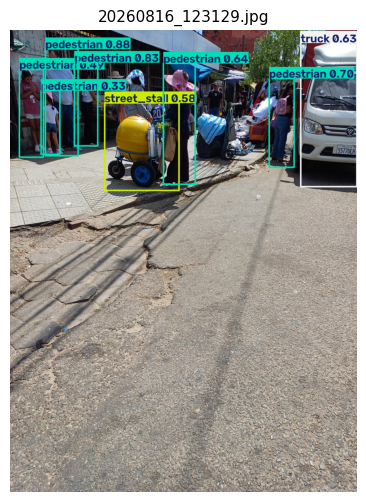

20260816_124322.jpg: 7 detecciones  ->  pedestrian 0.83, street_stall 0.54, pedestrian 0.42, street_stall 0.32, person_sitting 0.32, street_stall 0.30, street_stall 0.28


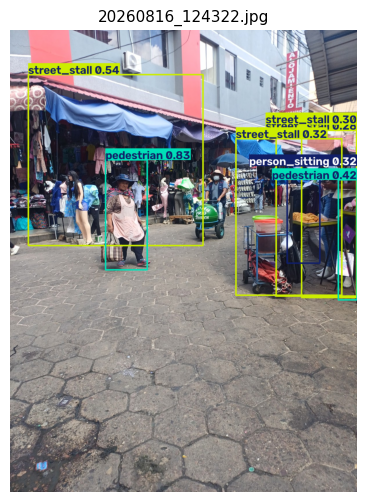

20260816_124559.jpg: 11 detecciones  ->  street_stall 0.84, car 0.84, motorbike 0.84, street_stall 0.65, pedestrian 0.63, pedestrian 0.63, street_vendor 0.60, pedestrian 0.56, pedestrian 0.44, car 0.40, pedestrian 0.33


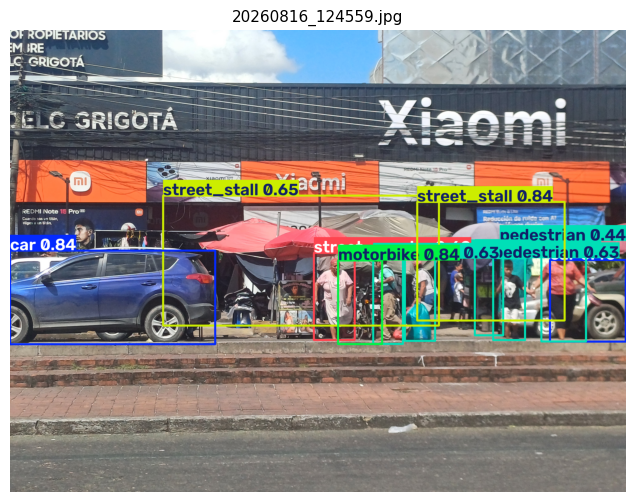

20260816_124602.jpg: 7 detecciones  ->  car 0.87, street_stall 0.80, street_stall 0.77, street_vendor 0.70, person_sitting 0.68, motorbike 0.38, pedestrian 0.28


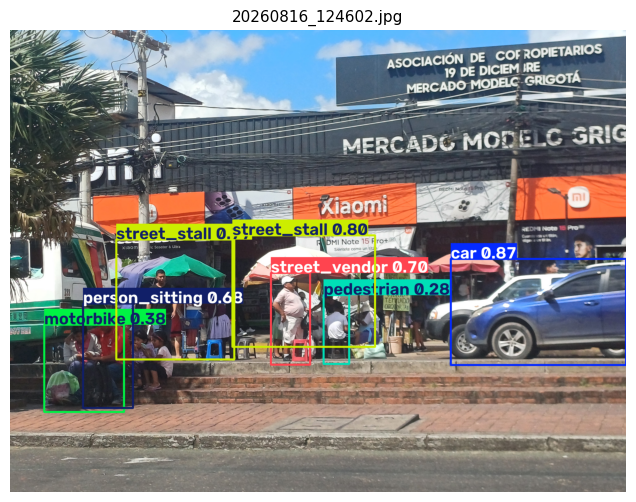

20260816_124659.jpg: 8 detecciones  ->  pedestrian 0.82, pedestrian 0.80, van 0.78, street_stall 0.60, street_stall 0.58, street_vendor 0.33, pedestrian 0.27, car 0.26


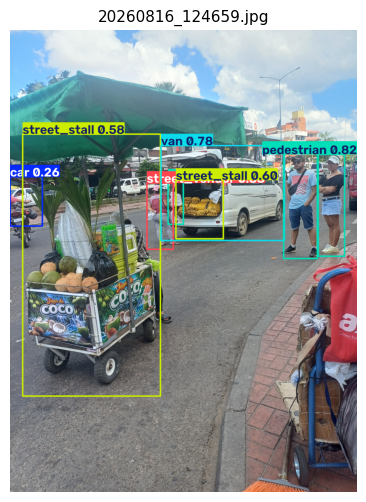

20260816_124758.jpg: 5 detecciones  ->  van 0.78, truck 0.54, street_stall 0.39, street_stall 0.32, car 0.29


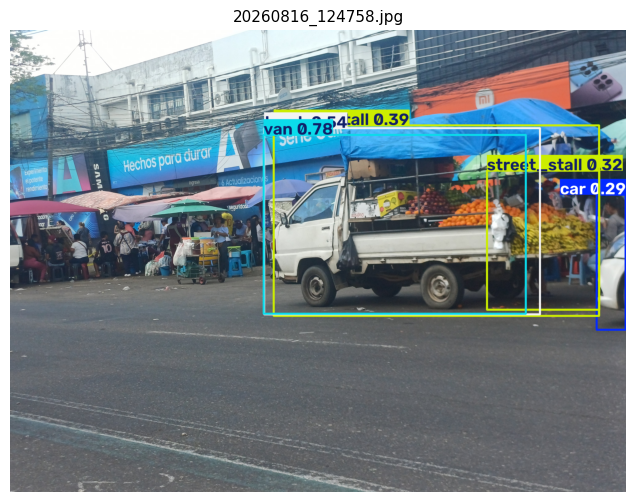

20260816_124852.jpg: 8 detecciones  ->  truck 0.93, van 0.78, street_stall 0.77, motorbike 0.53, car 0.51, motorbike 0.46, pedestrian 0.44, car 0.29


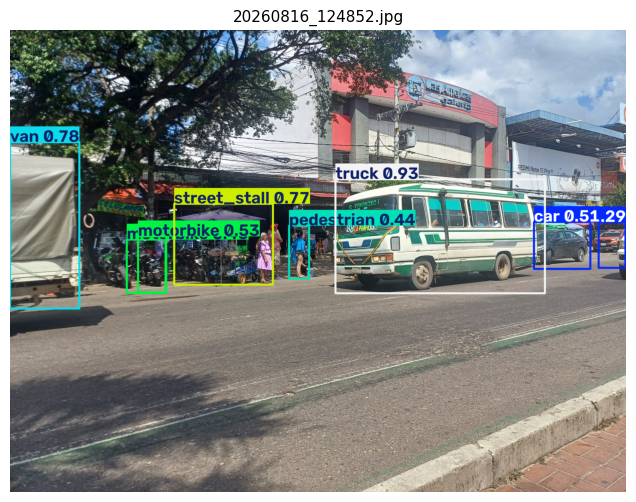

20260816_124924.jpg: 8 detecciones  ->  car 0.88, street_stall 0.84, car 0.73, motorbike 0.46, street_stall 0.37, street_vendor 0.33, street_stall 0.31, motorbike 0.29


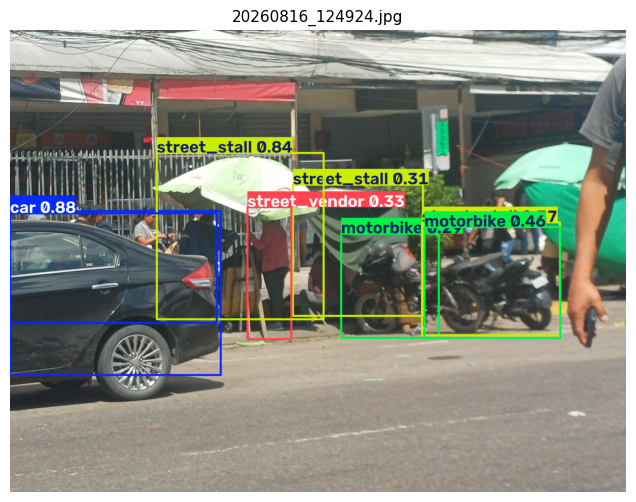

20260816_125125.jpg: 12 detecciones  ->  van 0.91, motorbike 0.81, motorbike 0.71, street_stall 0.70, pedestrian 0.70, pedestrian 0.59, motorbike 0.47, motorbike 0.38, motorbike 0.35, motorbike 0.30, car 0.29, motorbike 0.26


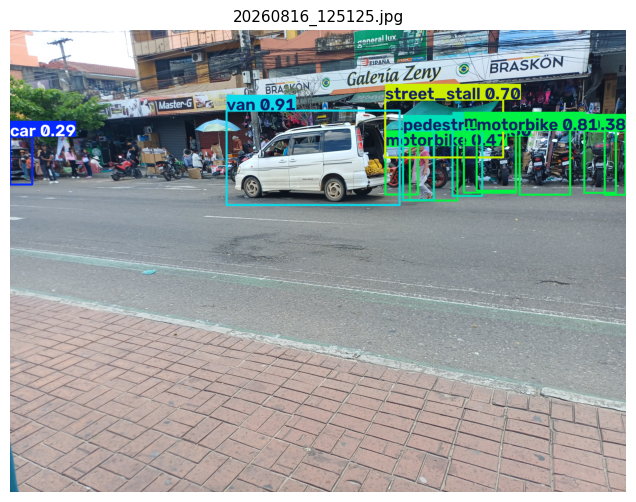

20260816_125135.jpg: 8 detecciones  ->  car 0.63, street_stall 0.49, motorbike 0.48, pedestrian 0.34, pedestrian 0.31, pedestrian 0.30, pedestrian 0.28, person_sitting 0.25


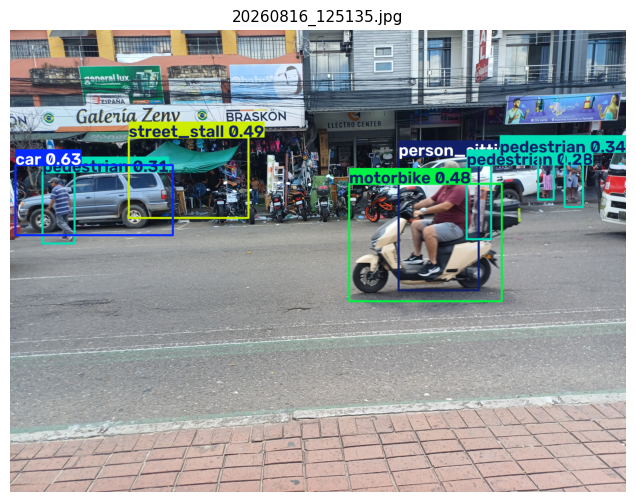

20260816_125224.jpg: 16 detecciones  ->  street_stall 0.94, pedestrian 0.91, pedestrian 0.88, street_stall 0.88, pedestrian 0.87, pedestrian 0.86, pedestrian 0.85, pedestrian 0.85, pedestrian 0.73, street_stall 0.71, pedestrian 0.69, street_stall 0.60, street_vendor 0.59, pedestrian 0.51, street_stall 0.43, street_stall 0.34


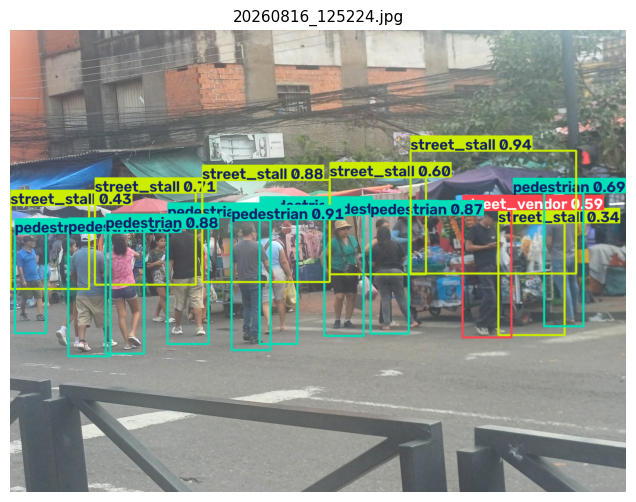

20260816_125822.jpg: 14 detecciones  ->  street_vendor 0.75, street_stall 0.68, street_stall 0.67, street_stall 0.56, street_vendor 0.42, street_stall 0.42, street_stall 0.41, street_vendor 0.40, pedestrian 0.37, street_vendor 0.34, pedestrian 0.30, person_sitting 0.30, pedestrian 0.29, street_vendor 0.27


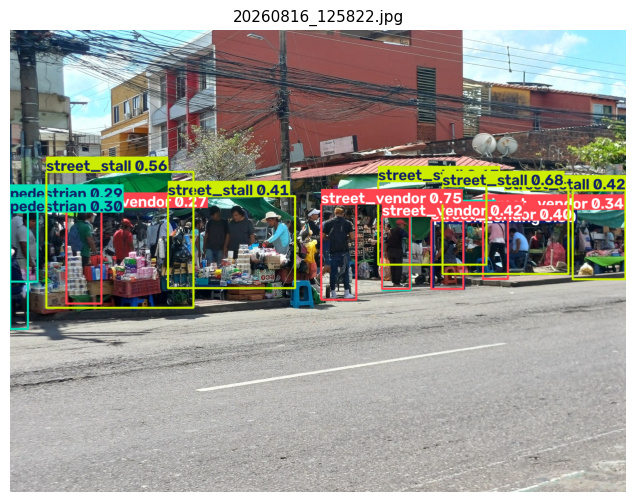

20260816_130039.jpg: 6 detecciones  ->  street_stall 0.86, pedestrian 0.84, street_stall 0.77, street_stall 0.77, street_vendor 0.64, car 0.59


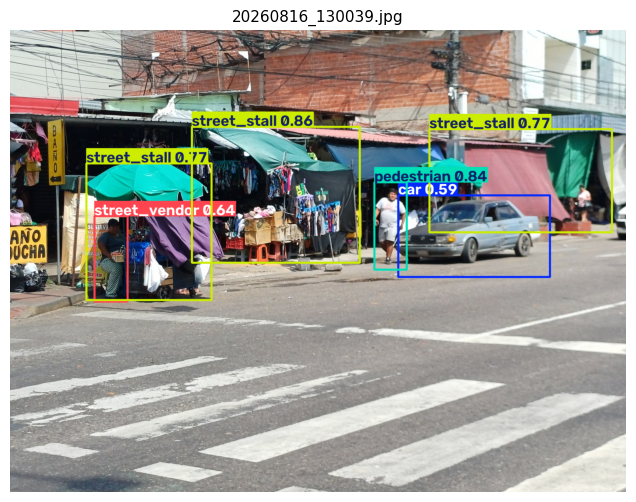

IMG_20260815_160235.jpg: 9 detecciones  ->  van 0.96, street_stall 0.83, pedestrian 0.71, street_vendor 0.46, street_vendor 0.44, street_stall 0.42, pedestrian 0.40, pedestrian 0.35, street_stall 0.31


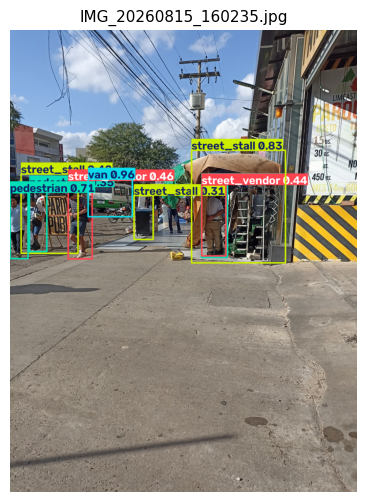

IMG_20260815_164504.jpg: 7 detecciones  ->  street_stall 0.91, pedestrian 0.83, car 0.81, pedestrian 0.62, pedestrian 0.58, pedestrian 0.57, street_stall 0.45


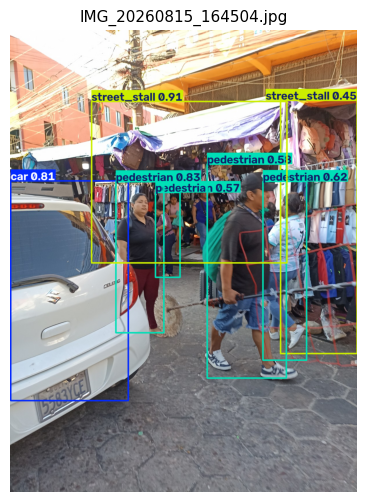

IMG_20260815_165811.jpg: 4 detecciones  ->  pedestrian 0.67, street_stall 0.63, street_vendor 0.31, street_stall 0.31


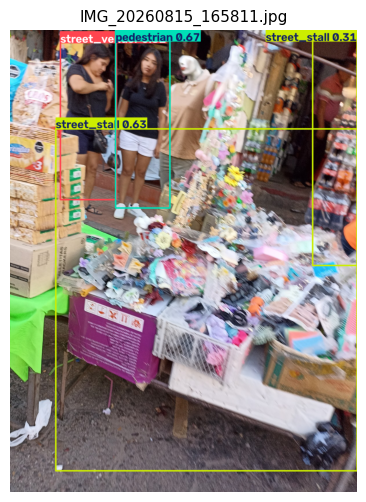


Tiempo medio de inferencia en CPU: 291 ms por imagen


In [8]:
UMBRAL_CONF = 0.25

resultados = {}
tiempos = []

for ruta in imagenes:
    t0 = time.perf_counter()
    res = modelo.predict(source=str(ruta), conf=UMBRAL_CONF, imgsz=640,
                         device=DISPOSITIVO, verbose=False)[0]
    tiempos.append((time.perf_counter() - t0) * 1000)
    resultados[ruta.name] = res

    detecciones = [f'{res.names[int(b.cls)]} {float(b.conf):.2f}' for b in res.boxes]
    print(f'{ruta.name}: {len(detecciones)} detecciones'
          + (f"  ->  {', '.join(detecciones)}" if detecciones else '  ->  ninguna'))

    plt.figure(figsize=(9, 6))
    plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(ruta.name, fontsize=11)
    plt.show()

print(f'\nTiempo medio de inferencia en CPU: {sum(tiempos)/len(tiempos):.0f} ms por imagen')

## 7. Comparación con las anotaciones de referencia

Para cada imagen, cuántos objetos anotó una persona y cuántos detectó el modelo.
No es una métrica formal —esa está en el informe y en `src/evaluate.py`— pero da una
idea inmediata de si el modelo se queda corto o se pasa de detecciones.


In [9]:
print(f"{'Imagen':<30}{'Anotadas':>10}{'Detectadas':>12}")
print('-' * 52)
tot_gt = tot_pred = 0

for ruta in imagenes:
    lbl = DIR_LABELS / (ruta.stem + '.txt')
    n_gt = 0
    if lbl.exists():
        n_gt = sum(1 for linea in lbl.read_text().splitlines() if linea.strip())
    n_pred = len(resultados[ruta.name].boxes)
    tot_gt += n_gt
    tot_pred += n_pred
    print(f'{ruta.name:<30}{n_gt:>10}{n_pred:>12}')

print('-' * 52)
print(f"{'TOTAL':<30}{tot_gt:>10}{tot_pred:>12}")

if tot_gt == 0:
    print('\nAviso: no se encontraron archivos .txt en datos/muestra/labels/.')

Imagen                          Anotadas  Detectadas
----------------------------------------------------
20260816_123129.jpg                   10           8
20260816_124322.jpg                    7           7
20260816_124559.jpg                    9          11
20260816_124602.jpg                   12           7
20260816_124659.jpg                    8           8
20260816_124758.jpg                    8           5
20260816_124852.jpg                    8           8
20260816_124924.jpg                    9           8
20260816_125125.jpg                   10          12
20260816_125135.jpg                    7           8
20260816_125224.jpg                   16          16
20260816_125822.jpg                   13          14
20260816_130039.jpg                    6           6
IMG_20260815_160235.jpg                8           9
IMG_20260815_164504.jpg                7           7
IMG_20260815_165811.jpg                5           4
----------------------------------------------

## 8. Conteo agregado por clase

Métrica de uso práctico para la aplicación: cuántas estructuras y vendedores detecta
el modelo en el conjunto de imágenes analizadas.


In [10]:
conteo = Counter()
for res in resultados.values():
    for b in res.boxes:
        conteo[res.names[int(b.cls)]] += 1

print(f"{'Clase':<18}{'Detecciones':>12}")
print('-' * 30)
for clase, n in conteo.most_common():
    print(f'{clase:<18}{n:>12}')
print('-' * 30)
print(f"{'TOTAL':<18}{sum(conteo.values()):>12}")

Clase              Detecciones
------------------------------
pedestrian                  45
street_stall                40
motorbike                   14
street_vendor               14
car                         13
van                          5
person_sitting               4
truck                        3
------------------------------
TOTAL                      138
